# Version 2: Analyze Region 6 - Iceland

Author: Ann Windnagel  
Date: May 2025

Description:  
This notebook analyzes the largest glaciers, ice caps, and ice fields in Region 6 - Iceland.  It processes Version 2 of the largest glacier data set using RGI 7 and GLIMS V20250603.

In [1]:
import os
import os.path as op
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import Polygon
import rasterio as rio
from rasterio.plot import plotting_extent
from earthpy import clip as cl
import earthpy.plot as ep

# set working dir
HOME = op.join(op.expanduser("~"))
os.chdir(os.path.join(HOME, "git/wgms-glacier-project"))

# Set up path to load scripts
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
import scripts.wgms_scripts as ws

# Set Up Region Info

In [2]:
# Set region number, region name, and region index
# Once these are set, this notebook should run automatically for the specified region
region_number = "6"
region_name = "Iceland"

# Note for the region index, region_index_1 should be one less than the region number and 
# region_index_2 should be equal to the region number. For example, for region 1, index_1 should be set to 0 and 
# index_2 should be set to 1, etc.
region_index_1 = 5
region_index_2 = 6

# This variable sets a value to determine whether the differences between the GLIMS and RGI glacier have been checked.
# When first starting a new notebook set handled to 0
# Once the differences have been checked and handled, set to 1 to pass the check 
# in the Compare Glaciers from GLIMS and RGI section towards the middele of this notebook.
handled = 1

# Set GLIMS version
#glims_version = '20230607'
glims_version = '20250603'

# Set RGI version
rgi_version = 7

# Set version number for the final data
final_version = 2

# * * * * * * * * Show Region Outline * * * * * * * *

In [3]:
# Open natural earth basemap TIF file
ne_fp = 'data/natural-earth/NE1_HR_LC_SR_W/NE1_HR_LC_SR_W.tif' # 10 m res
with rio.open(ne_fp) as ne_src:
    # Convert / read the data into a numpy array:
    ne_raster = ne_src.read()
    ne_src_extent = plotting_extent(ne_src)
    bounds = ne_src.bounds
    ne_raster_meta = ne_src.meta

In [4]:
# Open glacier regions
glacier_regions_fp = "data/gtn-g-glacier-regions/cleaned/GTN-G_glacier_regions_201707_cleaned.shp"
glacier_regions = gpd.read_file(glacier_regions_fp)

# Extract Region outline
region_outline = glacier_regions[region_index_1:region_index_2]

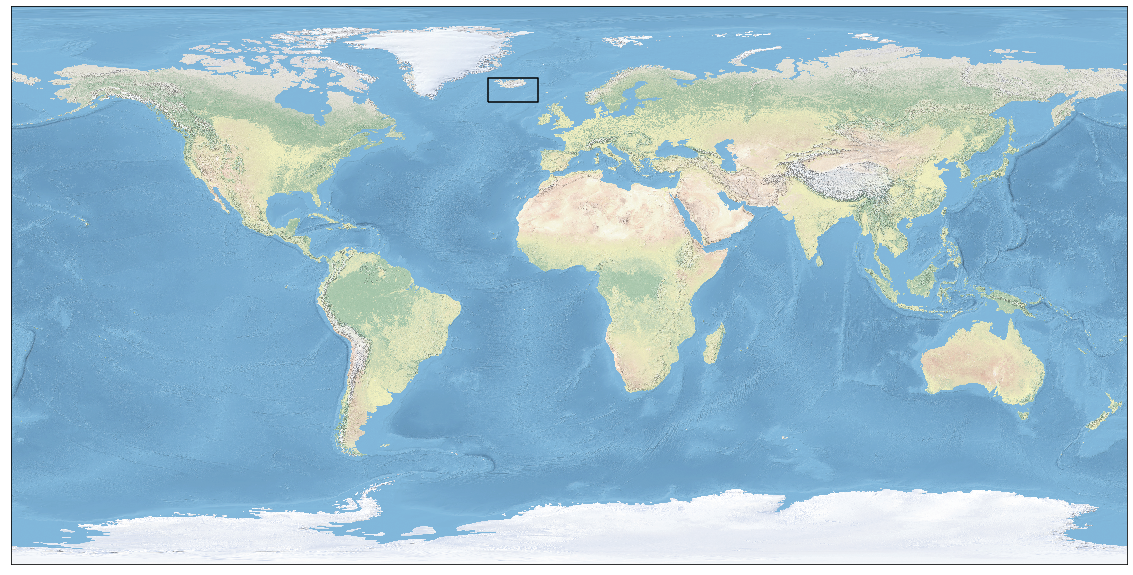

In [5]:
# Plot region outline over the natural earth
# Plot natural earth basemap
fig, ax = plt.subplots(figsize=(20, 20))

# Plot natural earth
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot region outline
region_outline.boundary.plot(ax=ax, color="black")

plt.show()

In [6]:
region_outline.bounds

,minx,miny,maxx,maxy
5,-26.0,59.0,-10.0,67.0


# * * * * * * * * Glacier Analysis * * * * * * * *

## Open GLIMS Largest Glaciers Data

In [7]:
# Open GLIMS largest glacier outlines for this region.
glims_glaciers_fn = "data/glims/processed/glims_version_" + glims_version + "/largest/glims_region_" + \
                     region_number + "_largest.shp"
glims_glaciers_df = gpd.read_file(glims_glaciers_fn)

In [8]:
# Check if GLIMS glacier names are of the "NoneType" because can't print legends and such if they are
# If they are, set them to a string "NONE"
glims_df_len = len(glims_glaciers_df)
for x in range(glims_df_len):
    if glims_glaciers_df['glac_name'][x] == None:
        print("GLIMS glacier " + str(x) + " equals none")
        glims_glaciers_df.loc[x, 'glac_name'] = 'NONE'

In [9]:
glims_glaciers_df

,region_no,glac_id,area,db_area,width,length,min_elev,mean_elev,max_elev,src_date,anlys_time,glac_name,geometry
0,6,G342858E64298N,1561.22,1561.220,0.0,0.0,111.0,0.0,1957.0,2000-09-09T00:00:00,1993-09-01T00:00:00,Skeidararjoekull,"POLYGON ((-16.886704 64.49112700000001, -16.88..."
1,6,G343733E64587N,1428.72,1428.720,0.0,0.0,649.0,0.0,1810.0,2000-09-09T00:00:00,1993-09-01T00:00:00,Bruarjoekull,"POLYGON ((-16.141494 64.78314, -16.140894 64.7..."
2,6,G343523E64267N,1067.74,1067.740,0.0,0.0,97.0,0.0,1878.0,2000-09-09T00:00:00,1993-09-01T00:00:00,Breidamerkurjoekull,"POLYGON ((-16.876255 64.49406999999999, -16.87..."
3,6,G342946E64674N,1060.64,1060.640,0.0,0.0,752.0,0.0,2000.0,2000-09-09T00:00:00,1993-09-01T00:00:00,Dyngjujoekull,"POLYGON ((-16.742387 64.827693, -16.736397 64...."
4,6,G339969E64642N,0.00,920.585,0.0,0.0,0.0,0.0,0.0,2000-08-20T00:00:00,2005-01-01T00:00:00,Langjoekull Ice Cap,"POLYGON ((-20.67335 64.596, -20.67194 64.59678..."


## Open RGI Largest Glaciers Data

In [10]:
# Open RGI largest glacier outlines for this region.
rgi_glaciers_fn = "data/rgi/processed/RGI-V" + str(rgi_version) + "/largest/rgi_region_" + region_number + "_largest.shp"
rgi_glaciers_df = gpd.read_file(rgi_glaciers_fn)

In [11]:
# Check if RGI glacier names are of the "NoneType" because can't print legends and such if they are
# If they are, set them to a string "NONE"
rgi_df_len = len(rgi_glaciers_df)
for x in range(rgi_df_len):
    if rgi_glaciers_df['Name'][x] == None:
        print("RGI glacier " + str(x) + " equals none")
        rgi_glaciers_df.loc[x, 'Name'] = 'NONE'

In [12]:
rgi_glaciers_df

,RGIId,o1region,GLIMSId,BgnDate,cenlon,cenlat,Area,primeclass,Connect,Name,geometry
0,RGI2000-v7.0-G-06-00227,06,G342858E64298N,2000-09-09T00:00:00,-17.120778,64.301186,1561.218060,0,0,Skeidararjoekull,"POLYGON Z ((-16.886704 64.49112700000001 0, -1..."
1,RGI2000-v7.0-G-06-00365,06,G343733E64587N,2000-09-09T00:00:00,-16.243015,64.597349,1428.724224,0,0,Bruarjoekull,"POLYGON Z ((-16.141494 64.78314 0, -16.140894 ..."
2,RGI2000-v7.0-G-06-00376,06,G343523E64267N,2000-09-09T00:00:00,-16.575932,64.275119,1067.744237,0,0,Breidamerkurjoekull,"POLYGON Z ((-16.876255 64.49406999999999 0, -1..."
3,RGI2000-v7.0-G-06-00375,06,G342946E64674N,2000-09-09T00:00:00,-17.085974,64.657872,1060.639153,0,0,Dyngjujoekull,"POLYGON Z ((-16.742387 64.827693 0, -16.736397..."
4,RGI2000-v7.0-G-06-00225,06,G342298E64282N,2000-09-09T00:00:00,-17.798810,64.290673,757.308202,0,0,Sidujoekull/Skaftarjoekull,"POLYGON Z ((-17.328649 64.39716199999999 0, -1..."


## Plot GLIMS Glaciers

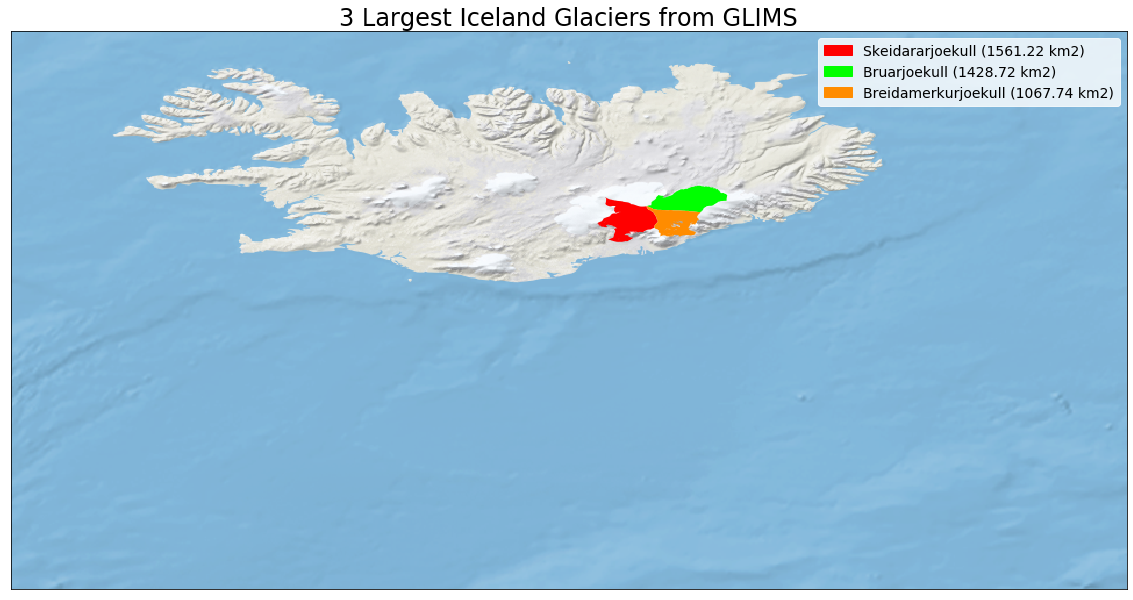

In [13]:
# Plot 3 largest glaciers on natural earth from GLIMS
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [glims_glaciers_df['glac_name'][0] + ' (' + str(glims_glaciers_df['db_area'][0]) + ' km2)',
                 glims_glaciers_df['glac_name'][1] + ' (' + str(glims_glaciers_df['db_area'][1]) + ' km2)',
                 glims_glaciers_df['glac_name'][2] + ' (' + str(glims_glaciers_df['db_area'][2]) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from glims dataframe
glims_glaciers_df.iloc[0:1].plot(ax=ax, color='red')
glims_glaciers_df.iloc[1:2].plot(ax=ax, color='lime')
glims_glaciers_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest ' + region_name + ' Glaciers from GLIMS', fontsize=24)
# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

## Plot RGI Glaciers

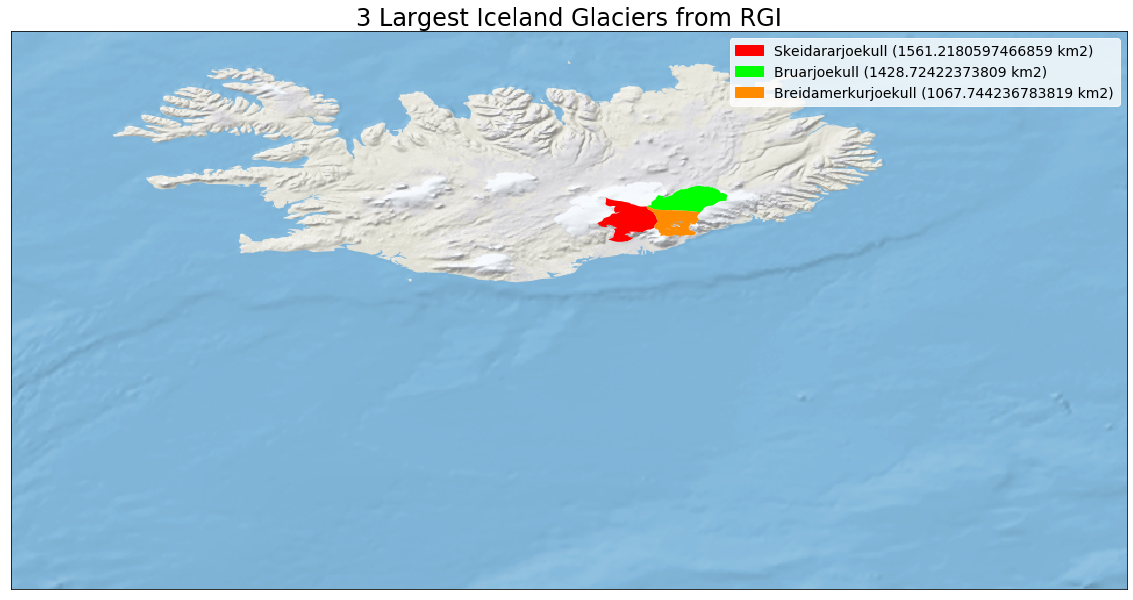

In [14]:
# Plot 3 largest glaciers on natural earth from RGI
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [rgi_glaciers_df['Name'][0] + ' (' + str(rgi_glaciers_df['Area'][0]) + ' km2)',
                 rgi_glaciers_df['Name'][1] + ' (' + str(rgi_glaciers_df['Area'][1]) + ' km2)',
                 rgi_glaciers_df['Name'][2] + ' (' + str(rgi_glaciers_df['Area'][2]) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from rgi dataframe
rgi_glaciers_df.iloc[0:1].plot(ax=ax, color='red')
rgi_glaciers_df.iloc[1:2].plot(ax=ax, color='lime')
rgi_glaciers_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest ' + region_name + ' Glaciers from RGI', fontsize=24)
# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

## Compare Glaciers from GLIMS and RGI
Do they match? If yes, continue, if no, stop notebook and investigate. Once the differences have been investigated and corrected in the code below this code block, set handled to 1 in the "Set Up Region Info" section at the top of the notebook, so that it passes this test.

In [15]:
if (glims_glaciers_df['glac_name'][0] == rgi_glaciers_df['Name'][0] and 
    glims_glaciers_df['glac_name'][1] == rgi_glaciers_df['Name'][1] and 
    glims_glaciers_df['glac_name'][2] == rgi_glaciers_df['Name'][2]):
    print("They match!")
else:
    if handled != 1:
        # If this hasn't been handled, stop execution
        class StopExecution(Exception):
            def _render_traceback_(self):
                pass

        print("They do NOT Match! Stopping notebook.")
        raise StopExecution
    else:
        # If this has been handled, continue execution
        print("They do not match but this has been handled in the code below this section, so continue.")

They match!


## Create Final Glacier Shapefiles
This section creates and formats the final glacier dataframe, plots it to make sure it looks ok, and saves it to a shapefile.

NOTE: The GLIMS v20190304 database contains outlines of the ice caps only and not the individual outlet glaciers. The RGI database does contain the glacier outlines, so for V1 used RGI for the glaciers.

GLIMS v20230607 has added the glacier outlines so can use those. The first largest is still an ice cap (Vatnajokull) but the 2nd, 3rd, and 4th match RGI 1st, 2nd, and 3rd. So for V2, can use both databases.

### Create final glacier dataframe

In [24]:
# Set up the final dataframe that will be used when saving the final shapefiles
# Drop columns that are not needed for the final data (use GLIMS dataframe for this)
final_glacier_data_df = glims_glaciers_df.drop(['area', 'width', 'length', 
                                                'min_elev', 'mean_elev', 'max_elev'], axis=1)

# Add region_name column
final_glacier_data_df['reg_name'] = region_name

# Rename some columns
final_glacier_data_df.rename(columns={'glac_id': 'glims_id', 'db_area': 'area_km2', 
                                       'src_date': 'date'}, inplace=True)

# Drop last 2 rows because they are the fourth and fifth largest glaciers and we aren't interested in them
final_glacier_data_df.drop([3, 4], inplace = True)
final_glacier_data_df.reset_index(drop=True, inplace=True)

# Add RGI ID column
final_glacier_data_df['rgi_id'] = (rgi_glaciers_df['RGIId'][0], rgi_glaciers_df['RGIId'][1], 
                                   rgi_glaciers_df['RGIId'][2])

# Add area_src column that gets filled lower down
final_glacier_data_df['area_src'] = '-999'

# Reorder the columns of the dataframe
final_glacier_data_df = final_glacier_data_df[['region_no', 'reg_name', 'glac_name', 'glims_id', 'rgi_id', 
                                               'area_km2', 'area_src', 'date', 'geometry']]

In [25]:
final_glacier_data_df

,region_no,reg_name,glac_name,glims_id,rgi_id,area_km2,area_src,date,geometry
0,6,Iceland,Skeidararjoekull,G342858E64298N,RGI2000-v7.0-G-06-00227,1561.22,-999,2000-09-09T00:00:00,"POLYGON ((-16.886704 64.49112700000001, -16.88..."
1,6,Iceland,Bruarjoekull,G343733E64587N,RGI2000-v7.0-G-06-00365,1428.72,-999,2000-09-09T00:00:00,"POLYGON ((-16.141494 64.78314, -16.140894 64.7..."
2,6,Iceland,Breidamerkurjoekull,G343523E64267N,RGI2000-v7.0-G-06-00376,1067.74,-999,2000-09-09T00:00:00,"POLYGON ((-16.876255 64.49406999999999, -16.87..."


In [31]:
# Calculate area and update dataframe as neccessary and clean the date format in the date column
# If GLIMS and RGI dates are the same year, then average the two areas.
# If GLIMS date is more recent, then use that measurement.
# If RGI date is more recent, then use that measurement.
# Note only comparing by year because sometimes the month and day are not known. Year matching is close enough.
for x in range(3):
    # Exract and clean GLIMS date so that it is comparable to RGI date
    glims_date = glims_glaciers_df['src_date'][x][0:10].replace('-', '')
    glims_year = glims_date[0:4]
    print('glims date: ' + glims_date)
    #print('glims year: ' + glims_year)
    
    # Extract RGI date
    rgi_date = rgi_glaciers_df['BgnDate'][x]
    rgi_year = rgi_date[0:4]
    print('rgi date: ' + rgi_date)
    #print('rgi year: ' + rgi_year)
    
    if glims_year == rgi_year:
        # Average GLIMS and RGI areas
        area = np.average([glims_glaciers_df['db_area'][x], rgi_glaciers_df['Area'][x]])
        area_src = 'A'
        print('Averaging area: ' + str(area))
    elif glims_year > rgi_year:
        # Use GLIMS area for the area
        area = glims_glaciers_df['db_area'][x]
        area_src = 'G'
        print('Using GLIMS area: ' + str(area))
    elif rgi_year > glims_year:
        # Use RGI area for the area
        area = rgi_glaciers_df['Area'][x]
        area_src = 'R'
        print('Using RGI area: ' + str(area))
    else:
        print("Error. Area could not be calculated.")
    
    print('')
    # Set the area and area source in the final dataframe
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('area_km2')] = area
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('area_src')] = area_src
    
    # Clean the date format in the final dataframe
    final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('date')] = \
        glims_glaciers_df['src_date'][x+1][0:10]
    
    # Update glacier names
    if x == 0:
        # Simply set the final df name to the rgi name
        final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('glac_name')] = \
        'Skeidararjökull'
    if x == 1:
        # Clean up the glacier name
        final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('glac_name')] = \
        'Bruarjökull'
    if x == 2:
        # Set this name to Barnes Ice Cap South-East Slope Glacier based on its location on Barnes ice cap
        final_glacier_data_df.iloc[x, final_glacier_data_df.columns.get_loc('glac_name')] = \
        'Breidamerkurjökull'

glims date: 20000909
rgi date: 2000-09-09T00:00:00
Averaging area: 1561.219029873343

glims date: 20000909
rgi date: 2000-09-09T00:00:00
Averaging area: 1428.722111869045

glims date: 20000909
rgi date: 2000-09-09T00:00:00
Averaging area: 1067.7421183919096



In [32]:
# Find the centroid of the glacier and add the lat/lon to the dataframe
centroidseries_gl = final_glacier_data_df['geometry'].centroid
    
final_glacier_data_df['cenlat'] = [centroidseries_gl.geometry.y[0], centroidseries_gl.geometry.y[1], 
                                   centroidseries_gl.geometry.y[2]]
final_glacier_data_df['cenlon'] = [centroidseries_gl.geometry.x[0], centroidseries_gl.geometry.x[1], 
                                   centroidseries_gl.geometry.x[2]]

# Add GLIMS and RGI version number metadata to dataframe for easy reference
final_glacier_data_df['glims_version'] = glims_version
final_glacier_data_df['rgi_version'] = str(rgi_version)

# Reorder the columns of the dataframe
final_glacier_data_df = final_glacier_data_df[['region_no', 'reg_name', 'glac_name', 'glims_id', 'rgi_id', 'area_km2',
                                               'area_src', 'date', 'cenlat', 'cenlon', 'glims_version', 'rgi_version', 
                                               'geometry']]

In [33]:
final_glacier_data_df

,region_no,reg_name,glac_name,glims_id,rgi_id,area_km2,area_src,date,cenlat,cenlon,glims_version,rgi_version,geometry
0,6,Iceland,Skeidararjökull,G342858E64298N,RGI2000-v7.0-G-06-00227,1561.219030,A,2000-09-09,64.297734,-17.141725,20250603,7,"POLYGON ((-16.886704 64.49112700000001, -16.88..."
1,6,Iceland,Bruarjökull,G343733E64587N,RGI2000-v7.0-G-06-00365,1428.722112,A,2000-09-09,64.586664,-16.267468,20250603,7,"POLYGON ((-16.141494 64.78314, -16.140894 64.7..."
2,6,Iceland,Breidamerkurjökull,G343523E64267N,RGI2000-v7.0-G-06-00376,1067.742118,A,2000-09-09,64.266639,-16.476734,20250603,7,"POLYGON ((-16.876255 64.49406999999999, -16.87..."


### Plot final glacier dataframe to check accuracy

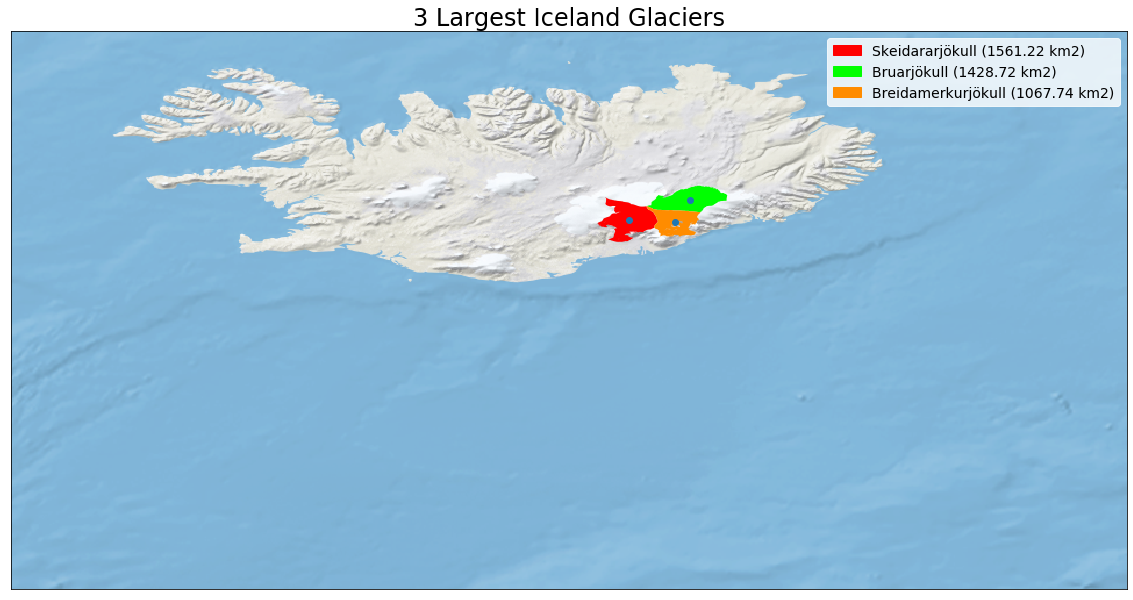

In [34]:
# Check that the geodataframe wasn't corrupted from these changes by plotting the data
# Plot 3 largest glaciers on natural earth from GLIMS
# Set up legend. Note that the sizes come from an average of GLIMS and RGI. 
# See wgms-glacier-project/data/comparison/compare-glims-rgi.xlsx
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [final_glacier_data_df['glac_name'][0] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][0], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][1] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][1], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][2] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][2], 2)) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from glims dataframe
final_glacier_data_df.iloc[0:1].plot(ax=ax, color='red')
final_glacier_data_df.iloc[1:2].plot(ax=ax, color='lime')
final_glacier_data_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest ' + region_name + ' Glaciers', fontsize=24)

# Plot the center points of the glacier complexes
centroidseries_gl.plot(ax=ax)

# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

### Create largest glacier shapefile from the final glacier dataframe

In [35]:
# Write dataframe to shapefile and save to zip if it doesn't already exist
glacier_zipfile_fn = "data/final-dataset/version-" + str(final_version) + "/region-" + \
                      region_number + "-largest-glaciers.zip"
if os.path.exists(glacier_zipfile_fn) == False:
    # Create the shapefile
    final_glacier_data_fn = "data/final-dataset/version-" + str(final_version) + "/region-" + \
                             region_number + "-largest-glaciers.shp"
    final_glacier_data_df.to_file(driver='ESRI Shapefile', filename=final_glacier_data_fn)
    
    # Zip up the shapefile
    glacier_zipfile_fn = ws.zipshp(final_glacier_data_fn, Delete=True)
    print("Creating zipfile: " + glacier_zipfile_fn)
else:
    print(glacier_zipfile_fn + " already extists")

Creating zipfile: data/final-dataset/version-2\region-6-largest-glaciers.zip


# * * * * * * * * Ice Cap Analysis * * * * * * * *

NOTE: The GLIMS database contians the ice cap outlines for Region 6, so don't need to do the extra "explode" step. Can just take the information and outlines straight out of GLIMS.

The following code that examines the "exploded" data is left here for reference.

In [23]:
# Set flag run_icecap to 1 when you are ready to run the ice cap analysis. If it's not 1, stop the notebook
# This stop allows you to just run the whole notebook when you are still working on the glacier analysis
run_icecap = 0
if run_icecap != 1:
    # If this hasn't been handled, stop execution
    class StopExecution(Exception):
        def _render_traceback_(self):
            pass
    print("Not ready to run ice cap analysis. Stopping notebook.")
    raise StopExecution

Not ready to run ice cap analysis. Stopping notebook.


In [ ]:
# Open this regions ice caps from the exploded version
# Ice cap/icefield epsg code used for calculating area
ic_epsg = '3057'
ice_caps_ex_fn = "data/glims/processed/ice-caps/largest/largest-ice-caps-region_" + \
                  region_number + "_epsg" + ic_epsg + ".shp"
ice_caps_ex_df = gpd.read_file(ice_caps_ex_fn)

In [ ]:
ice_caps_ex_df

In [ ]:
# Plot this regions ice caps in one frame
# Set up legend, note these ice cap names are not correct
legend_colors = ['darkorange', 'red', 'blue', 'purple', 'pink', 'yellow', 'green', 'cyan', 'magenta', 'lime']
legend_labels = ['Penny Ice Cap (1771)', 'Barnes Ice Cap (3382)', 'Bylot Island Ice Cap (3251)', 
                 'Cape Macculloch Ice Cap? (3344)', 'Unknown (1795)', 'Unknown (1915)', 'Unknown (3487)', 
                 'Unknown (3346)', 'Unknown (1904)', 'Unknown (3343)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot largest
ice_caps_ex_df.iloc[0:1].plot(ax=ax, color="darkorange")
ice_caps_ex_df.iloc[1:2].plot(ax=ax, color="red")
ice_caps_ex_df.iloc[2:3].plot(ax=ax, color="blue")
ice_caps_ex_df.iloc[3:4].plot(ax=ax, color="purple")
ice_caps_ex_df.iloc[4:5].plot(ax=ax, color="pink")
ice_caps_ex_df.iloc[5:6].plot(ax=ax, color="yellow")
ice_caps_ex_df.iloc[6:7].plot(ax=ax, color="green")
ice_caps_ex_df.iloc[7:8].plot(ax=ax, color="cyan")
ice_caps_ex_df.iloc[8:9].plot(ax=ax, color="magenta")
ice_caps_ex_df.iloc[9:10].plot(ax=ax, color="lime")
ax.set_title('Largest ' + region_name + ' Ice Caps/Icefields', fontsize=24)
ax.set_axis_off()

# Add legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

In [ ]:
# Stop notebook and examine ice caps and icefields. 
# Comment this out when not needed.
#class StopExecution(Exception):
#    def _render_traceback_(self):
#        pass

#print("Stopping notebook to examine glacier complexes.")
#raise StopExecution

## Create Final Ice Catchment Data Frame
This ice catchment data frame will then be saved to a shapefile.

NOTE: The original polygons from the GLIMS database are used instead of the exploded data (ice_caps_ex_df).

In [ ]:
# Update and reorganize ice_caps_ex_df to create final df
# Drop uneeded columns
final_catchment_data_df = glims_glaciers_df.drop(['area', 'width', 'length', 'src_date',
                                                  'min_elev', 'mean_elev', 'max_elev', 'glac_name'], axis=1)

# Drop last 2 rows because only interested in the top 3 ice caps
final_catchment_data_df.drop([3, 4], inplace = True)

# Add region_no column
final_catchment_data_df['region_no'] = region_number

# Add region_name column
final_catchment_data_df['reg_name'] = region_name

# Add catchment names
final_catchment_data_df['ic_name'] = ['Vatnajökull Ice Cap', 'Langjökull Ice Cap', 'Hofsjökull Ice Cap']

In [ ]:
final_catchment_data_df

In [ ]:
# Add the dates to the dataframe
vatna_glaciers_min_date = glims_glaciers_df.iloc[0]['src_date'][0:10]
vatna_glaciers_max_date = glims_glaciers_df.iloc[0]['src_date'][0:10]
lang_glaciers_min_date = glims_glaciers_df.iloc[1]['src_date'][0:10]
lang_glaciers_max_date = glims_glaciers_df.iloc[1]['src_date'][0:10]
hofs_glaciers_min_date = glims_glaciers_df.iloc[2]['src_date'][0:10]
hofs_glaciers_max_date = glims_glaciers_df.iloc[2]['src_date'][0:10]
final_catchment_data_df['min_date'] = [vatna_glaciers_min_date, lang_glaciers_min_date, hofs_glaciers_min_date]
final_catchment_data_df['max_date'] = [vatna_glaciers_max_date, lang_glaciers_max_date, hofs_glaciers_max_date]

# Drop the glac_id
final_catchment_data_df = final_catchment_data_df.drop(['glac_id'], axis=1)

# Reorder the columns
final_catchment_data_df = final_catchment_data_df[['region_no', 'reg_name', 'ic_name', 'db_area', 
                                                   'min_date', 'max_date', 'geometry']]

# Rename some columns
final_catchment_data_df.rename(columns={'db_area': 'area_km2'}, inplace=True)
                                     
# Reset index
final_catchment_data_df = final_catchment_data_df.reset_index(drop=True)

In [ ]:
# Find the centroid of the glacier complex and add the lat/lon to the dataframe
centroidseries = final_catchment_data_df['geometry'].centroid

In [ ]:
# Add lat/lon
final_catchment_data_df['cenlat'] = [centroidseries.geometry.y[0], centroidseries.geometry.y[1], 
                                     centroidseries.geometry.y[2]]
final_catchment_data_df['cenlon'] = [centroidseries.geometry.x[0], centroidseries.geometry.x[1], 
                                     centroidseries.geometry.x[2]]

# Reorder the columns
final_catchment_data_df = final_catchment_data_df[['region_no', 'reg_name', 'ic_name', 'area_km2', 
                                                   'min_date', 'max_date', 'cenlat', 'cenlon', 'geometry']]

In [ ]:
final_catchment_data_df

### Plot the final catchment dataframe to verify it looks correct

In [ ]:
# Plot this regions ice caps in one frame
# Set up legend
legend_colors = ['darkorange', 'red', 'blue']
legend_labels = [final_catchment_data_df['ic_name'][0] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][0], 2)) + ' km2)', 
                 final_catchment_data_df['ic_name'][1] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][1], 2)) + ' km2)', 
                 final_catchment_data_df['ic_name'][2] + \
                 ' (' + str(round(final_catchment_data_df['area_km2'][2], 2)) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20, 20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap for Region 7
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot largest
final_catchment_data_df.iloc[0:1].plot(ax=ax, color="darkorange")
final_catchment_data_df.iloc[1:2].plot(ax=ax, color="red")
final_catchment_data_df.iloc[2:3].plot(ax=ax, color="blue")
ax.set_title('Largest ' + region_name + ' Ice Caps/Icefields', fontsize=24)
ax.set_axis_off()

# Plot the center points of the glacier complexes
centroidseries.plot(ax=ax)

# Add legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

### Save final catchment dataframe to a shapefile

In [ ]:
# Write dataframe to shapefile and save to zip if it doesn't already exist
catchment_zipfile_fn = "data/final-dataset/region-" + region_number + "-largest-complexes.zip"
if os.path.exists(catchment_zipfile_fn) == False:
    # Create the shapefile
    final_catchment_data_fn = "data/final-dataset/region-" + region_number + "-largest-complexes.shp"
    final_catchment_data_df.to_file(driver='ESRI Shapefile', filename=final_catchment_data_fn)
    
    # Zip up the shapefile
    catchment_zipfile_fn = ws.zipshp(final_catchment_data_fn, Delete=True)
    print("Creating zipfile: " + catchment_zipfile_fn)
else:
    print(catchment_zipfile_fn + " already extists")

In [ ]:
# Save the glims ids to a text file
text_file_1st_fn = "data/final-dataset/region-" + region_number + "-1st-largest-glims-ids.txt"
if os.path.exists(text_file_1st_fn) == False:
    print("Creating text file: " + text_file_1st_fn)
    text_file = open(text_file_1st_fn, "w")
    n = text_file.write(glims_glaciers_df.iloc[0:1]['glac_id'][0])
    text_file.close()
else:
    print(text_file_1st_fn + " already extists")
    
text_file_2nd_fn = "data/final-dataset/region-" + region_number + "-2nd-largest-glims-ids.txt"
if os.path.exists(text_file_2nd_fn) == False:
    print("Creating text file: " + text_file_2nd_fn)
    text_file = open(text_file_2nd_fn, "w")
    n = text_file.write(glims_glaciers_df.iloc[1:2]['glac_id'][1])
    text_file.close()
else:
    print(text_file_2nd_fn + " already extists")
    
text_file_3rd_fn = "data/final-dataset/region-" + region_number + "-3rd-largest-glims-ids.txt"
if os.path.exists(text_file_3rd_fn) == False:
    print("Creating text file: " + text_file_3rd_fn)
    text_file = open(text_file_3rd_fn, "w")
    n = text_file.write(glims_glaciers_df.iloc[2:3]['glac_id'][2])
    text_file.close()
else:
    print(text_file_3rd_fn + " already extists")